In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

In [2]:
file_paths = {
    'Alzheimer': 'matrices/matriz_AD.csv',
    'Control Alzheimer': 'matrices/matriz_CNAD.csv',
    'DCL': 'matrices/matriz_MCI.csv',
    'Control DCL': 'matrices/matriz_CNMCI.csv'
}

try:
    correlation_matrices = {name: pd.read_csv(path, header=0).values for name, path in file_paths.items()}
    print("✅ Matrices loaded successfully from CSV files.")
except FileNotFoundError as e:
    print(f"❌ Error: Could not find the file {e.filename}.")
    exit()

# Definir metricas a plotear
metrics_to_plot = {
    'Avg Path Length': [],
    'Global Efficiency': [],
    'Avg Clustering Coefficient': [],
    'Avg Betweenness Centrality': [],
    'Avg Closeness Centrality': [],
    'Modularity': [],
    'Transitivity': []
}

group_names = list(correlation_matrices.keys())
#threshold = 0.5 # DEFINIR VALOR
threshold = np.percentile([m for m in correlation_matrices.values()], 90) #binarization, e.g., keep the top 10% of connections
for group_name, matrix in correlation_matrices.items():
    adj_matrix = (np.abs(matrix) > threshold).astype(int)
    G = nx.from_numpy_array(adj_matrix)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Calcular metricas
    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
    else:
        avg_path_length = np.nan # NaN para grafos no conectados
        
    global_efficiency = nx.global_efficiency(G)
    avg_clustering_coefficient = nx.average_clustering(G)
    avg_betweenness = np.mean(list(nx.betweenness_centrality(G).values()))
    avg_closeness = np.mean(list(nx.closeness_centrality(G).values()))

    try:
        communities = nx.community.greedy_modularity_communities(G)
        modularity = nx.community.modularity(G, communities)
    except:
        modularity = np.nan

    transitivity = nx.transitivity(G)

    # Guardar cada métrica
    metrics_to_plot['Avg Path Length'].append(avg_path_length)
    metrics_to_plot['Global Efficiency'].append(global_efficiency)
    metrics_to_plot['Avg Clustering Coefficient'].append(avg_clustering_coefficient)
    metrics_to_plot['Avg Betweenness Centrality'].append(avg_betweenness)
    metrics_to_plot['Avg Closeness Centrality'].append(avg_closeness)
    metrics_to_plot['Modularity'].append(modularity)
    metrics_to_plot['Transitivity'].append(transitivity)

# CDataFrame 
df_metrics = pd.DataFrame(metrics_to_plot, index=group_names)
print(df_metrics)

✅ Matrices loaded successfully from CSV files.
                   Avg Path Length  Global Efficiency  \
Alzheimer                 2.481115           0.464101   
Control Alzheimer              NaN           0.565277   
DCL                            NaN           0.464267   
Control DCL                    NaN           0.147878   

                   Avg Clustering Coefficient  Avg Betweenness Centrality  \
Alzheimer                            0.544511                    0.004970   
Control Alzheimer                    0.600349                    0.003223   
DCL                                  0.521481                    0.004777   
Control DCL                          0.378294                    0.010528   

                   Avg Closeness Centrality  Modularity  Transitivity  
Alzheimer                          0.415593    0.375333      0.444053  
Control Alzheimer                  0.515622    0.226357      0.508734  
DCL                                0.419083    0.411882      0.43

## Bar Chart for Comparison

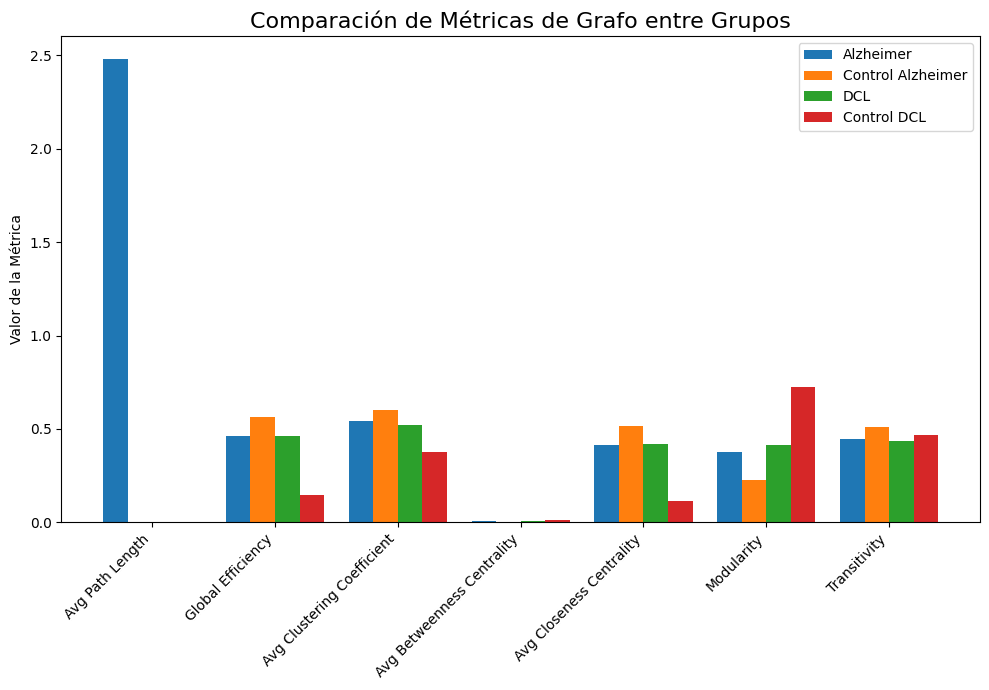

In [ ]:
# Create a grouped bar chart for all metrics
metrics_names = list(df_metrics.columns)
num_metrics = len(metrics_names)
num_groups = len(group_names)
bar_width = 0.2 

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(num_metrics)

for i in range(num_groups):
    group_values = df_metrics.iloc[i].values
    ax.bar(x + i * bar_width, group_values, bar_width, label=group_names[i])

ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas de Grafo entre Grupos', fontsize=16)
ax.set_xticks(x + bar_width * (num_groups - 1) / 2)
ax.set_xticklabels(metrics_names, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Spider Chart - REVISAR ******


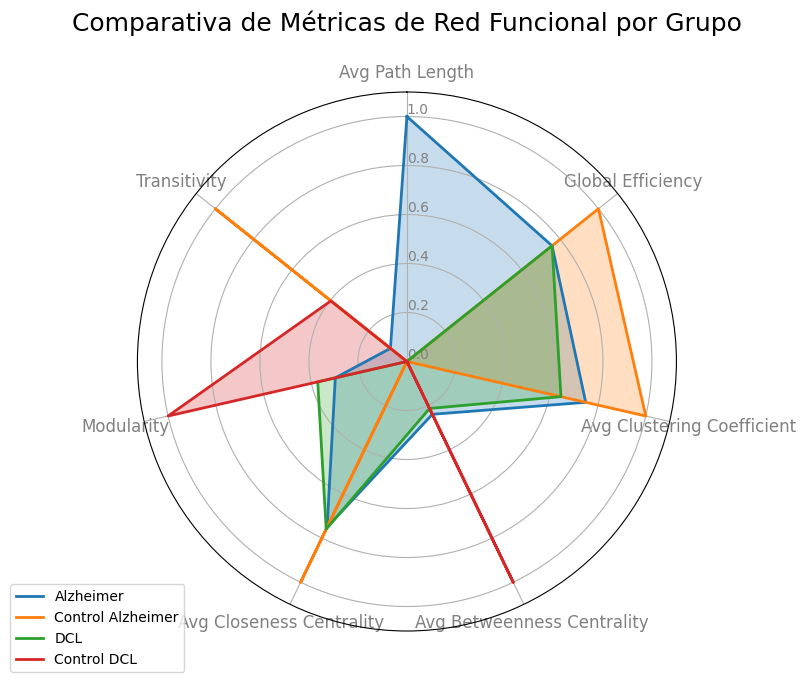

In [4]:
# 2. Manejo de valores NaN y normalización de los datos
# Remplazamos los valores NaN con 0 para que la normalización funcione correctamente
df_filled = df_metrics.fillna(0)
# Normalizamos cada columna a una escala de 0 a 1
df_normalized = (df_filled - df_filled.min()) / (df_filled.max() - df_filled.min())

# 3. Preparación de los datos para el ploteo
categories = list(df_normalized.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Cierra el círculo
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Colores para cada línea

# 4. Configuración del gráfico de radar (spider chart)
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks(np.arange(0, 1.1, 0.2), ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.1)

# 5. Iterar sobre cada grupo y trazar su perfil en el gráfico
for i, group in enumerate(df_metrics.index):
    values = df_normalized.loc[group].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=group, color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.25)

# 6. Añadir títulos y leyenda para una mejor visualización
plt.title('Comparativa de Métricas de Red Funcional por Grupo', size=18, color='black', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# 7. Mostrar el gráfico
plt.show()